# Minimal orbital example: $sp_z$, $p_x$, and $p_y$

This notebook draws simple analytic, hydrogen-like orbital slices. It is an illustration of orbital orientation and phase, not a DFT or transport calculation. The contact axis is $z$.

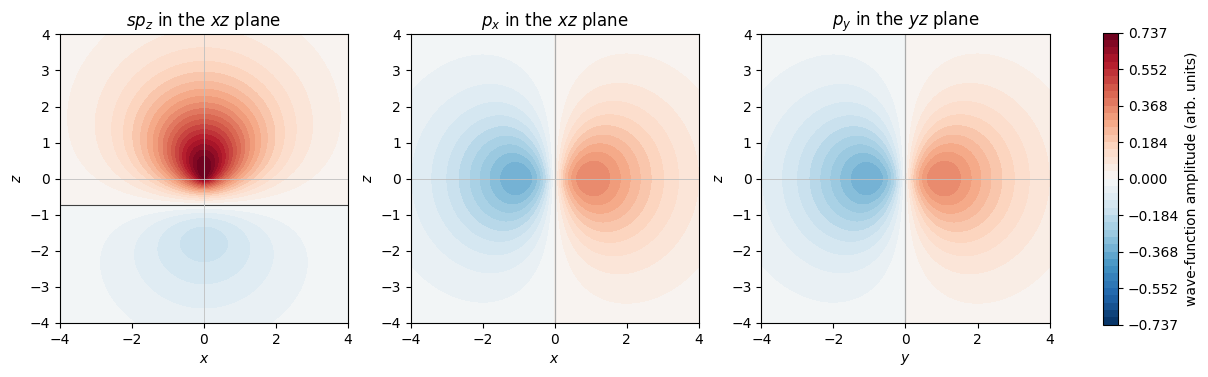

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Two-dimensional coordinate grid in arbitrary units.
u = np.linspace(-4.0, 4.0, 501)
horizontal, vertical = np.meshgrid(u, u)
radius = np.sqrt(horizontal**2 + vertical**2)
radial_decay = np.exp(-radius)

# Real orbital amplitudes. For the sp_z panel, horizontal=x and vertical=z.
# The relative coefficient is chosen only to make both hybrid lobes visible.
s = radial_decay
p_horizontal = horizontal * radial_decay
p_vertical = vertical * radial_decay
sp_vertical = (s + 1.35 * p_vertical) / np.sqrt(2.0)

orbitals = [
    (sp_vertical, r"$sp_z$ in the $xz$ plane", r"$x$", r"$z$"),
    (p_horizontal, r"$p_x$ in the $xz$ plane", r"$x$", r"$z$"),
    (p_horizontal, r"$p_y$ in the $yz$ plane", r"$y$", r"$z$"),
]

peak = max(np.max(np.abs(field)) for field, *_ in orbitals)
levels = np.linspace(-peak, peak, 41)
norm = TwoSlopeNorm(vmin=-peak, vcenter=0.0, vmax=peak)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for ax, (field, title, xlabel, ylabel) in zip(axes, orbitals):
    image = ax.contourf(
        horizontal, vertical, field, levels=levels, cmap="RdBu_r", norm=norm
    )
    ax.contour(horizontal, vertical, field, levels=[0.0], colors="0.25", linewidths=0.8)
    ax.axhline(0.0, color="0.75", linewidth=0.6)
    ax.axvline(0.0, color="0.75", linewidth=0.6)
    ax.set(
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        aspect="equal",
        xlim=(-4, 4),
        ylim=(-4, 4),
    )

fig.colorbar(image, ax=axes, shrink=0.82, label="wave-function amplitude (arb. units)")
plt.show()

## Rotatable three-dimensional surfaces

The surface radius represents the magnitude of the angular orbital amplitude. Red and blue again mark opposite phases. Run `%matplotlib widget` before this cell if `ipympl` is installed and you want rotation directly inside the notebook.

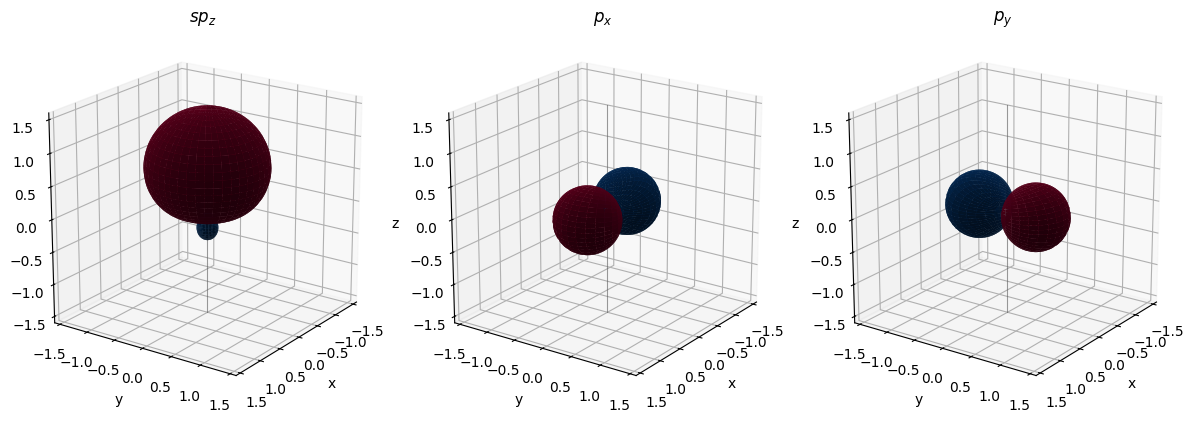

In [2]:
# Uncomment for interactive rotation when ipympl is available:
# %matplotlib widget

theta = np.linspace(0.0, np.pi, 120)
phi = np.linspace(0.0, 2.0 * np.pi, 180)
theta, phi = np.meshgrid(theta, phi)

# Unit-vector components. The transport direction is z.
nx = np.sin(theta) * np.cos(phi)
ny = np.sin(theta) * np.sin(phi)
nz = np.cos(theta)

angular_orbitals = [
    (0.55 + nz, r"$sp_z$"),
    (nx, r"$p_x$"),
    (ny, r"$p_y$"),
]

fig = plt.figure(figsize=(12, 4), constrained_layout=True)
for index, (amplitude, title) in enumerate(angular_orbitals, start=1):
    ax = fig.add_subplot(1, 3, index, projection="3d")
    orbital_radius = np.abs(amplitude)
    x = orbital_radius * nx
    y = orbital_radius * ny
    z = orbital_radius * nz
    phase_colors = plt.cm.RdBu_r((np.sign(amplitude) + 1.0) / 2.0)
    ax.plot_surface(
        x, y, z, facecolors=phase_colors, linewidth=0, antialiased=True, shade=True
    )
    ax.plot([0, 0], [0, 0], [-1.6, 1.6], color="0.35", linewidth=0.8, alpha=0.6)
    ax.set(
        title=title,
        xlabel="x",
        ylabel="y",
        zlabel="z",
        xlim=(-1.6, 1.6),
        ylim=(-1.6, 1.6),
        zlim=(-1.6, 1.6),
    )
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=20, azim=35)

plt.show()

## Reading the plot

Red and blue indicate opposite wave-function phases, not different charges. The $sp_z$ hybrid points mainly along the contact axis and can therefore form the dominant axial channel. The $p_x$ and $p_y$ orbitals are transverse to that axis. In an approximately axial contact they are symmetry-related and can have similar transmissions. Bending or laterally shifting the contact breaks this equivalence.